In [76]:
import pandas as pd 

We convert both of the datasets into dataframes, so that we can then work with them.

In [81]:
df_labels= pd.read_csv('GalaxyZoo1_DR_table2.csv', sep=";")
df_physics= pd.read_csv('Skyserver_SQL2_27_2018 6_51_39 PM.csv', sep=";")

print("LABEL COLUMNS: ", df_labels.columns)
print("PHYSICS COLUMNS: ", df_physics.columns)

LABEL COLUMNS:  Index(['OBJID', 'RA', 'DEC', 'NVOTE', 'P_EL', 'P_CW', 'P_ACW', 'P_EDGE',
       'P_DK', 'P_MG', 'P_CS', 'P_EL_DEBIASED', 'P_CS_DEBIASED', 'SPIRAL',
       'ELLIPTICAL', 'UNCERTAIN'],
      dtype='object')
PHYSICS COLUMNS:  Index(['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'rerun', 'camcol',
       'field', 'specobjid', 'class', 'redshift', 'plate', 'mjd', 'fiberid'],
      dtype='object')


At this point we know several things:
- OBJID don't match, so we have to merge both dataframes using another parameter: the location in space ('ra' and 'dec' columns)
- the name of columns must be both in upper or in lower letters
- types of both dataframes in 'ra' and 'dec' columns must match
- some columns are unnecessary
So, the next step must be to adapt and clear the dataframes.

In [ ]:
#functions to convert types
def ra_sexadecimal_to_degrees(ra:str):
    h, m, s = map(float, ra.split(":"))
    return (h + m/60 + s/3600) * 15 # 1 hour -> 15 degrees

def dec_sexadecimal_to_degrees(dec:str):
    sign= -1 if dec[0]== "-" else 1
    dec= dec[1:] if dec[0]=="-" else dec
    d, m, s = map(float, dec.split(":"))
    return sign * (d + m/60 + s/3600)

#Rename the physis id column
df_physics.rename(columns= {"ra":"RA", "dec":'DEC'}, inplace= True)
print(df_physics.columns)

#convert types
df_labels['RA'] = df_labels['RA'].apply(ra_sexadecimal_to_degrees).round(4)
df_labels['DEC'] = df_labels['DEC'].apply(dec_sexadecimal_to_degrees).round(4)

df_physics['RA'] = df_physics['RA'].round(4)
df_physics['DEC'] = df_physics['DEC'].round(4)

#We delete the columns we are not interested in
df_physics = df_physics[['RA', 'DEC', 'u', 'g', 'r', 'i', 'z']]
df_labels = df_labels[['RA', 'DEC', 'P_EL', 'P_CS', 'SPIRAL', 'ELLIPTICAL', 'UNCERTAIN']]


Now that we have both of the dataframes clean, it's time to merge them

In [ ]:
df_galaxies= pd.merge(df_physics, df_labels, on=['DEC', 'RA'])
print(len(df_galaxies))
print(df_galaxies)

We now get the proportions of the classes.

In [88]:
# get rid of the uncertain data
df_galaxies = df_galaxies[df_galaxies['UNCERTAIN'] == 0]

# get the proportions of classes
proportion_elliptical=0
proportion_spiral=0

for i in range (len(df_galaxies)):
    if df_galaxies.iloc[i]['ELLIPTICAL']==1:
        proportion_elliptical+=1
    else:
        proportion_spiral+=1

proportion_elliptical/=len(df_galaxies)
proportion_spiral/=len(df_galaxies)
print("PROPORTION OF ELLIPTICAL GALAXIES: ", proportion_elliptical)
print("PROPORTION OF SPIRAL GALAXIES: ", proportion_spiral)


PROPORTION OF ELLIPTICAL GALAXIES:  0.20054384772263767
PROPORTION OF SPIRAL GALAXIES:  0.7994561522773623


It's time of Feature Engineering. My next steps is to create a new column with *Color Indices*, since this is crucial to identify wether a galaxy is elliptical or spiral. This is given by the fact that ellipticals are younger and brighter, so they emit a lot of u and g and their color is blue; meanwhile spirals emit more r and i and the color is red, as they are older and colder.
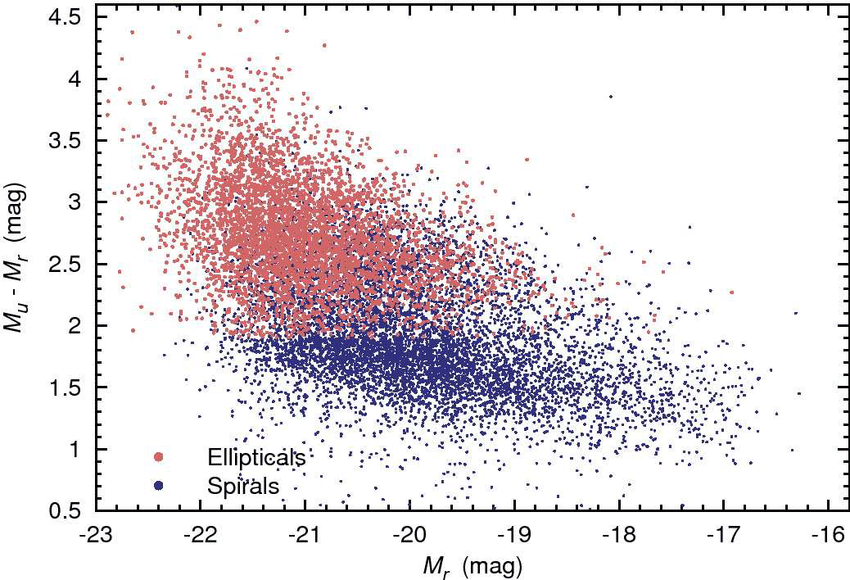

In [ ]:
#creating new columns 
df_galaxies['u-g']= df_galaxies['u']-df_galaxies['g']
df_galaxies['g-r']= df_galaxies['g']-df_galaxies['r']
df_galaxies['r-i']= df_galaxies['r']-df_galaxies['i']


* Decide which columns are "Features" (X) and which are "Labels" (Y)
* Convert the spiral and elliptical columns into one unique column
* Split the data into train and test sets